# 05 · The age mix of software developers (CPS microdata, 2020–2026)

**Question.** If generative AI substitutes for junior developers, the youngest workers' share of software-developer employment should fall after late 2022, *relative to other occupations*. This notebook is the household-survey counterpart to Brynjolfsson, Chandar & Chen's (2025) analysis of ADP payroll data. The CPS is a public, representative survey; ADP data is proprietary.

**Data.** Census Bureau / BLS Current Population Survey, basic monthly public-use microdata from January 2020 to the latest month, restricted to employed persons aged 16+.
- **Software** means Census occupation codes 1021 (software developers) and 1022 (QA analysts & testers), pooled. Computer programmers (1010) are kept separate.
- **Weights:** employment uses `pwcmpwgt` (4 implied decimals). Weekly earnings (`pternwa`, 2 implied decimals, top-coded at $2,884.61) come from outgoing-rotation respondents only and use `pworwgt`.

**Design.**
1. Employment by age band.
2. The young (22–25) share of employment, software versus other occupations, by year relative to 2022.
3. A permutation of the pre→post change in young share across all large occupations.
4. An occupation × month fixed-effects regression.
5. Weekly earnings by age.

**Caveats.**
- CPS respondents stay in the sample for 8 of 16 months, so monthly observations are not independent. The naive standard errors below overstate precision.
- Cells are small: about 40 software developers aged 22–25 per month.
- Occupation is self-reported.

In [1]:
import sys, json
from pathlib import Path
sys.path.insert(0, str(Path.cwd().resolve().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

from common import *
set_style()
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

In [2]:
files = sorted((RAW / "cps").glob("*_employed.csv.gz"))
cps = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
no_occ = cps.ptio1ocd.isna() | (cps.ptio1ocd < 0)
print(f"Dropping {no_occ.sum():,} employed person-months with no occupation code ({no_occ.mean():.2%})")
cps = cps[~no_occ].copy()
cps["ptio1ocd"] = cps.ptio1ocd.astype(int)
cps["w"] = cps.pwcmpwgt / 1e4                                  # 4 implied decimals
cps["date"] = pd.to_datetime(dict(year=cps.hryear4, month=cps.hrmonth, day=1))
cps["year"] = cps.hryear4
SOFTWARE = [1021, 1022]
cps["software"] = cps.ptio1ocd.isin(SOFTWARE)
cps["occ"] = cps.ptio1ocd.where(~cps.software, 1021).astype(int)   # pool QA testers with developers
cps["age_band"] = pd.cut(cps.prtage, [15, 21, 25, 30, 40, 200], labels=["16-21", "22-25", "26-30", "31-40", "41+"])
cps["young"] = cps.prtage.between(22, 25).astype(float)

monthly_emp = cps.groupby("date").w.sum() / 1e6
nmonths = cps.groupby("year").date.nunique()
print(f"{cps.date.nunique()} months, {cps.date.min():%Y-%m} to {cps.date.max():%Y-%m}; {len(cps):,} employed person-months")
print(f"Weighted employment per month: {monthly_emp.min():.1f}M to {monthly_emp.max():.1f}M "
      "(BLS household-survey employment was roughly 133-163M over this period)")
print("Months per year:", nmonths.to_dict())
all_months = pd.date_range(cps.date.min(), cps.date.max(), freq="MS")
print("Months with no public-use file on the Census server:", [f"{d:%Y-%m}" for d in all_months.difference(cps.date.unique())])
print("Unweighted software person-months per year:", cps[cps.software].groupby("year").size().to_dict())

Dropping 0 employed person-months with no occupation code (0.00%)


79 months, 2020-01 to 2026-08; 3,722,523 employed person-months
Weighted employment per month: 133.3M to 164.1M (BLS household-survey employment was roughly 133-163M over this period)
Months per year: {2020: 12, 2021: 12, 2022: 12, 2023: 12, 2024: 12, 2025: 11, 2026: 8}
Months with no public-use file on the Census server: ['2025-10']
Unweighted software person-months per year: {2020: 6560, 2021: 6818, 2022: 7048, 2023: 6993, 2024: 6857, 2025: 6142, 2026: 4612}


In [3]:
import re
titles = {}
for line in (RAW / "cps" / "cps_2026_record_layout_and_codes.txt").read_text(errors="ignore").splitlines():
    m = re.match(r"^\s*(\d{4})\s+(\d{2}-\d{2}[0-9X]{2})\s+(.+?)\s*$", line)
    if m:
        titles[int(m.group(1))] = m.group(3)
titles[1021] = "Software developers & QA testers"
print(len(titles), "occupation titles parsed from the Census code list")

516 occupation titles parsed from the Census code list


## 1. Software employment by age band (annual averages of monthly weighted counts)

Software developers & QA testers employed (thousands; 2026 = months available so far)


age_band,16-21,22-25,26-30,31-40,41+,All ages
year,,,,,,
2020,15.0,176.0,321.0,693.0,761.0,1968.0
2021,17.0,151.0,386.0,666.0,784.0,2005.0
2022,14.0,181.0,391.0,695.0,886.0,2166.0
2023,19.0,176.0,402.0,742.0,872.0,2211.0
2024,19.0,171.0,386.0,717.0,865.0,2158.0
2025,10.0,208.0,403.0,776.0,930.0,2327.0
2026,16.0,186.0,472.0,866.0,1032.0,2573.0


Index, 2022 = 100


age_band,16-21,22-25,26-30,31-40,41+,All ages
year,,,,,,
2020,112.1,97.6,82.1,99.8,85.9,90.8
2021,127.1,83.4,98.7,96.0,88.5,92.6
2022,100.0,100.0,100.0,100.0,100.0,100.0
2023,141.3,97.5,102.7,106.8,98.4,102.1
2024,140.7,94.6,98.6,103.3,97.6,99.6
2025,74.0,115.3,103.1,111.7,105.0,107.4
2026,113.4,103.1,120.8,124.7,116.5,118.8


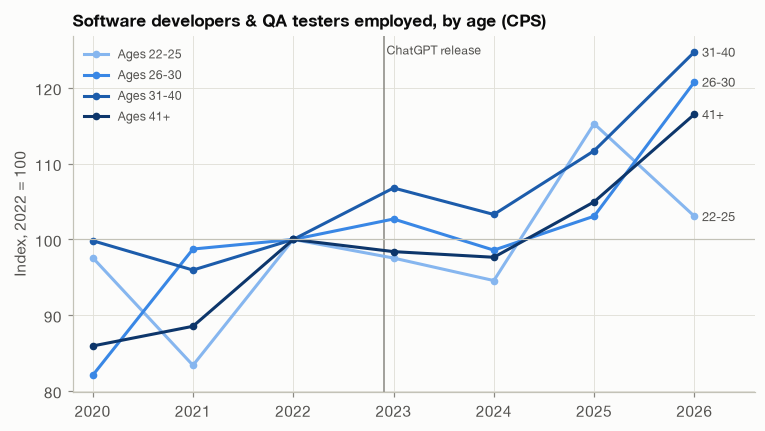

In [4]:
sw = cps[cps.software]
emp_age = (sw.groupby(["year", "age_band"], observed=True).w.sum().unstack()
             .div(nmonths, axis=0) / 1e3)[["16-21", "22-25", "26-30", "31-40", "41+"]]
emp_age["All ages"] = emp_age.sum(axis=1)
emp_idx = emp_age / emp_age.loc[2022] * 100
print("Software developers & QA testers employed (thousands; 2026 = months available so far)")
display(emp_age.round(0))
print("Index, 2022 = 100")
display(emp_idx.round(1))

fig, ax = plt.subplots(figsize=(8, 4.2))
for band, c in zip(["22-25", "26-30", "31-40", "41+"], ORDINAL_BLUE):
    ax.plot(emp_idx.index, emp_idx[band], color=c, marker="o", ms=4, label=f"Ages {band}")
    label_end(ax, emp_idx.index[-1], emp_idx[band].iloc[-1], band)
ax.axhline(100, color=BASELINE, lw=0.8)
mark_chatgpt(ax, x=2022.9)
ax.set_xticks(emp_idx.index)
ax.set_xlim(emp_idx.index[0] - 0.2, emp_idx.index[-1] + 0.6)
ax.set_ylabel("Index, 2022 = 100")
ax.set_title("Software developers & QA testers employed, by age (CPS)")
ax.legend(loc="upper left", fontsize=8)
save(fig, "05_cps_software_employment_by_age");

## 2. Young (22–25) share of employment: software vs. all other occupations (workers aged 22–64)

,young 22-25 (%) | other occ.,young 22-25 (%) | software,young 22-27 (%) | other occ.,young 22-27 (%) | software,n | other occ.,n | software,gap 22-25 (pp),gap vs 2022 (pp),naive SE software (pp)
year,,,,,,,,,
2020,8.72,9.25,13.72,16.02,490178,6315,0.53,0.76,0.36
2021,8.85,7.76,13.88,15.60,500831,6553,-1.09,-0.86,0.33
2022,8.82,8.59,13.63,16.02,487299,6798,-0.23,0.00,0.34
2023,9.28,8.30,14.05,14.93,478962,6676,-0.98,-0.75,0.34
2024,9.00,8.15,13.77,14.01,475901,6638,-0.85,-0.62,0.34
2025,8.94,9.19,13.72,15.27,414822,5928,0.25,0.48,0.38
2026,9.18,7.47,14.16,14.65,288430,4426,-1.70,-1.47,0.40


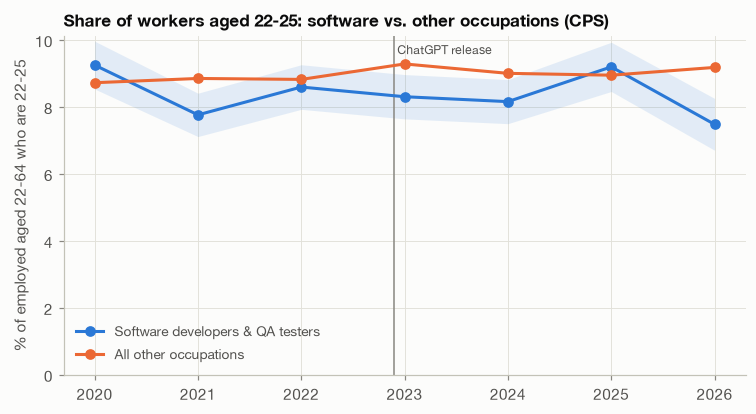

In [5]:
prime = cps[cps.prtage.between(22, 64)].copy()
prime["young27"] = prime.prtage.between(22, 27).astype(float)
g = (prime.assign(wy=prime.w * prime.young, wy27=prime.w * prime.young27)
          .groupby(["year", "software"])[["wy", "wy27", "w"]].sum())
n = prime.groupby(["year", "software"]).size()
share = pd.DataFrame({
    "young 22-25 (%)": g.wy / g.w * 100,
    "young 22-27 (%)": g.wy27 / g.w * 100,
    "n": n,
}).unstack("software")
share.columns = [f"{a} | {'software' if b else 'other occ.'}" for a, b in share.columns]
share["gap 22-25 (pp)"] = share["young 22-25 (%) | software"] - share["young 22-25 (%) | other occ."]
share["gap vs 2022 (pp)"] = share["gap 22-25 (pp)"] - share.loc[2022, "gap 22-25 (pp)"]
p = share["young 22-25 (%) | software"] / 100
share["naive SE software (pp)"] = np.sqrt(p * (1 - p) / share["n | software"]) * 100
display(share.round(2))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(share.index, share["young 22-25 (%) | software"], color=BLUE, marker="o", label="Software developers & QA testers")
ax.fill_between(share.index, share["young 22-25 (%) | software"] - 1.96 * share["naive SE software (pp)"],
                share["young 22-25 (%) | software"] + 1.96 * share["naive SE software (pp)"],
                color=BLUE, alpha=0.12, lw=0)
ax.plot(share.index, share["young 22-25 (%) | other occ."], color=ORANGE, marker="o", label="All other occupations")
mark_chatgpt(ax, x=2022.9)
ax.set_xticks(share.index)
ax.set_ylim(0, None)
ax.set_ylabel("% of employed aged 22-64 who are 22-25")
ax.set_title("Share of workers aged 22-25: software vs. other occupations (CPS)")
ax.legend(loc="lower left")
save(fig, "05_cps_young_share");

## 3. Permutation across occupations

For every occupation with at least 800 person-month observations in each period, compute the change in the young (22–25) share of its 22–64 workforce.
- **Pre:** Jan 2021–Nov 2022 (2020 is skipped because of COVID).
- **Post:** Jan 2023 onward.

Software's change is then ranked against all of them, both in percentage points and in log ratio (post/pre). The log ratio matters because occupations that start with many young workers can lose more percentage points.

In [6]:
per = prime[(prime.date >= "2021-01-01") & ((prime.date < POST_START) | (prime.date >= "2023-01-01"))].copy()
per["period"] = np.where(per.date < POST_START, "pre", "post")
agg = (per.assign(wy=per.w * per.young).groupby(["occ", "period"])
          .agg(wy=("wy", "sum"), w=("w", "sum"), n=("w", "size")).unstack("period"))
ok = (agg["n"]["pre"] >= 800) & (agg["n"]["post"] >= 800)
sh = (agg["wy"] / agg["w"])[ok] * 100
perm = pd.DataFrame({"pre_share": sh["pre"], "post_share": sh["post"]})
perm["pp_change"] = perm.post_share - perm.pre_share
perm["log_ratio"] = np.log(perm.post_share / perm.pre_share)
perm["title"] = perm.index.map(lambda c: titles.get(c, str(c)))
perm["n_pre"], perm["n_post"] = agg["n"]["pre"][ok], agg["n"]["post"][ok]

s = perm.loc[1021]
res = {}
for col in ["pp_change", "log_ratio"]:
    others = perm[col].drop(1021)
    res[col] = {"software": s[col], "rank (1 = largest fall)": int((perm[col] < s[col]).sum() + 1),
                "n occupations": len(perm), "one-sided perm. p": ((others <= s[col]).sum() + 1) / (len(others) + 1),
                "median other occ.": others.median()}
print(f"Software: young share {s.pre_share:.2f}% pre -> {s.post_share:.2f}% post")
display(pd.DataFrame(res).T.round(3))

computing = perm[(perm.index >= 1005) & (perm.index <= 1240)].sort_values("log_ratio")
print("Computer & mathematical occupations in the comparison set:")
display(computing[["title", "pre_share", "post_share", "pp_change", "log_ratio", "n_post"]].round(2))
print("Largest relative falls in young share:")
display(perm.sort_values("log_ratio").head(12)[["title", "pre_share", "post_share", "pp_change", "log_ratio"]].round(2))

Software: young share 8.14% pre -> 8.32% post


,software,rank (1 = largest fall),n occupations,one-sided perm. p,median other occ.
pp_change,0.179,102.0,222.0,0.459,0.404
log_ratio,0.022,101.0,222.0,0.455,0.046


Computer & mathematical occupations in the comparison set:


,title,pre_share,post_share,pp_change,log_ratio,n_post
occ,,,,,,
1065,Database administrators and architects,5.93,2.88,-3.05,-0.72,1548
1220,Operations research analysts,8.88,4.51,-4.37,-0.68,2032
1105,Network and computer systems administrators,4.42,3.17,-1.25,-0.33,1950
1108,"Computer occupations, all other",7.19,5.56,-1.63,-0.26,12432
1240,Other mathematical science occupations,11.52,9.20,-2.32,-0.22,5395
1050,Computer support specialists,8.72,7.50,-1.22,-0.15,7042
1021,Software developers & QA testers,8.14,8.32,0.18,0.02,23668
1007,Information security analysts,7.81,8.46,0.65,0.08,2678
1006,Computer systems analysts,7.10,8.51,1.41,0.18,5788


Largest relative falls in young share:


,title,pre_share,post_share,pp_change,log_ratio
occ,,,,,
3010,Dentists,1.14,0.09,-1.06,-2.58
300,Architectural and engineering managers,2.01,0.53,-1.49,-1.34
3090,Physicians,0.56,0.19,-0.37,-1.06
1065,Database administrators and architects,5.93,2.88,-3.05,-0.72
1220,Operations research analysts,8.88,4.51,-4.37,-0.68
3515,Medical records specialists,5.96,3.12,-2.84,-0.65
3630,Massage therapists,5.57,3.04,-2.53,-0.60
910,Credit counselors and loan officers,6.57,3.82,-2.75,-0.54
5840,Insurance claims and policy processing clerks,8.40,5.03,-3.36,-0.51


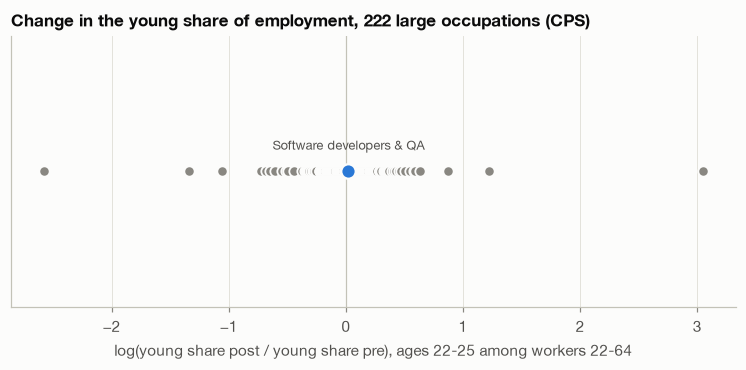

In [7]:
d = perm.sort_values("log_ratio")
fig, ax = plt.subplots(figsize=(8.5, 3.2))
others = d.drop(index=1021)
ax.scatter(others.log_ratio, np.zeros(len(others)), s=46, color=MUTED, edgecolor=SURFACE, lw=1.2, zorder=3,
           label="Other occupations")
ax.scatter([d.loc[1021, "log_ratio"]], [0], s=90, color=BLUE, edgecolor=SURFACE, lw=1.5, zorder=4,
           label="Software developers & QA")   # drawn last so the dense middle doesn't hide it
ax.annotate("Software developers & QA", (d.loc[1021, "log_ratio"], 0), xytext=(0, 14), textcoords="offset points",
            ha="center", fontsize=8.5, color=INK_2)
ax.set_yticks([]); ax.grid(axis="y", visible=False)
ax.axvline(0, color=BASELINE, lw=0.8)
ax.set_xlabel("log(young share post / young share pre), ages 22-25 among workers 22-64")
ax.set_title(f"Change in the young share of employment, {len(d)} large occupations (CPS)")
save(fig, "05_cps_young_share_permutation");

## 4. Occupation × month fixed-effects regression

The unit is an occupation × month cell covering the large occupations above. The outcome is the cell's weighted young (22–25) share, in percentage points. The regression includes occupation and month fixed effects, weights cells by their weighted employment, and clusters standard errors by occupation. With a single treated occupation the clustered SE is optimistic, so the permutation rank above is the better guide to inference.

In [8]:
cells = (per[per.occ.isin(perm.index)].assign(wy=lambda d: d.w * d.young)
            .groupby(["occ", "date"]).agg(wy=("wy", "sum"), w=("w", "sum")).reset_index())
cells["young_pct"] = cells.wy / cells.w * 100
cells["sw_post"] = ((cells.occ == 1021) & (cells.date >= POST_START)).astype(float)
fe = smf.wls("young_pct ~ sw_post + C(occ) + C(date)", data=cells, weights=cells.w).fit(
    cov_type="cluster", cov_kwds={"groups": pd.factorize(cells.occ)[0]})
print(f"Software x post: {fe.params.sw_post:+.2f} pp (clustered SE {fe.bse.sw_post:.2f}); "
      f"pre-period software young share {s.pre_share:.2f}% -> implied relative change {fe.params.sw_post / s.pre_share:+.0%}")
print(f"cells: {len(cells):,}; occupations: {cells.occ.nunique()}")

Software x post: -0.04 pp (clustered SE 0.10); pre-period software young share 8.14% -> implied relative change -0%
cells: 14,652; occupations: 222


## 5. Weekly earnings by age (outgoing-rotation respondents, workers aged 22–64)

Software developers & QA testers: median weekly earnings ($), share top-coded (%), n


median_weekly                         pct_topcoded                       n                 
age_band         22-25   26-30   31-40     41+        22-25 26-30 31-40   41+ 22-25 26-30 31-40  41+
year                                                                                                
2020            1442.0  1923.0  1923.0  2115.0          8.0  20.0  22.0  24.0   125   249   564  634
2021            1442.0  1826.0  1960.0  2080.0         11.0  19.0  22.0  25.0   125   302   546  666
2022            1596.0  2269.0  2308.0  2308.0          4.0  32.0  34.0  34.0   136   291   573  667
2023            1731.0  2019.0  2308.0  2308.0         19.0  25.0  35.0  31.0   127   295   592  651
2024            1920.0  2281.0  2460.0  2500.0         17.0  24.0  36.0  37.0   119   305   563  662
2025            1920.0  2180.0  2600.0  2700.0         17.0  26.0  40.0  41.0   113   254   488  570
2026            2020.0  2300.0  2660.0  2700.0         20.0  34.0  36.0  38.0    72   185   388  447

Young-to-prime median earnings ratios


,software: 22-25 / 31-40,software: 26-30 / 31-40,other occ.: 22-25 / 31-40
year,,,
2020,0.750,1.000,0.624
2021,0.736,0.931,0.634
2022,0.692,0.983,0.655
2023,0.750,0.875,0.636
2024,0.780,0.927,0.638
2025,0.738,0.838,0.646
2026,0.759,0.865,0.642


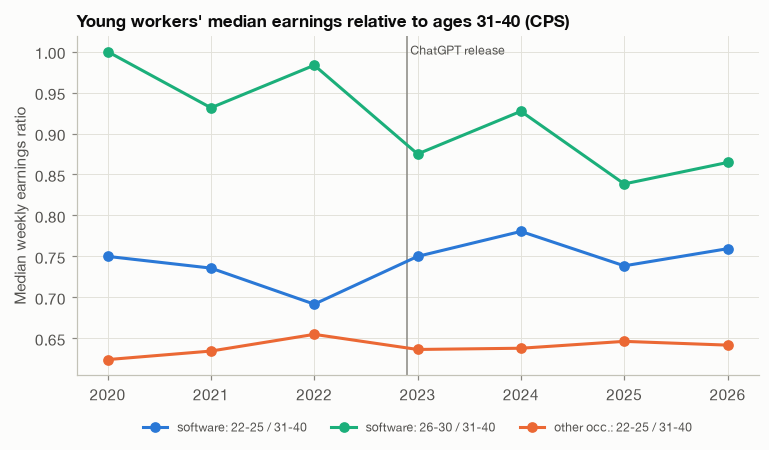

In [9]:
org = cps[(cps.pternwa > 0) & (cps.pworwgt > 0) & cps.prtage.between(22, 64)].copy()
org["weekly"] = org.pternwa / 100
org["topcoded"] = (org.pternwa >= 288461).astype(float)
org["ow"] = org.pworwgt / 1e4

def wq(x, w, q=0.5):
    o = np.argsort(x.values); xs, ws = x.values[o], w.values[o]; c = np.cumsum(ws)
    return xs[np.searchsorted(c, q * c[-1])]

def earn_table(d):
    rows = []
    for (y, b), grp in d.groupby(["year", "age_band"], observed=True):
        rows.append({"year": y, "age_band": b, "median_weekly": wq(grp.weekly, grp.ow),
                     "pct_topcoded": np.average(grp.topcoded, weights=grp.ow) * 100, "n": len(grp)})
    return pd.DataFrame(rows).pivot(index="year", columns="age_band")

e_sw, e_other = earn_table(org[org.software]), earn_table(org[~org.software])
print("Software developers & QA testers: median weekly earnings ($), share top-coded (%), n")
display(e_sw.round(0))

ratio = pd.DataFrame({
    "software: 22-25 / 31-40": e_sw["median_weekly"]["22-25"] / e_sw["median_weekly"]["31-40"],
    "software: 26-30 / 31-40": e_sw["median_weekly"]["26-30"] / e_sw["median_weekly"]["31-40"],
    "other occ.: 22-25 / 31-40": e_other["median_weekly"]["22-25"] / e_other["median_weekly"]["31-40"],
})
print("Young-to-prime median earnings ratios")
display(ratio.round(3))

fig, ax = plt.subplots(figsize=(8, 4))
for col, c in zip(ratio.columns, [BLUE, AQUA, ORANGE]):
    ax.plot(ratio.index, ratio[col], color=c, marker="o", label=col)
mark_chatgpt(ax, x=2022.9)
ax.set_xticks(ratio.index)
ax.set_ylabel("Median weekly earnings ratio")
ax.set_title("Young workers' median earnings relative to ages 31-40 (CPS)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=3, fontsize=8)
save(fig, "05_cps_earnings_ratio");

In [10]:
emp_age.to_csv(PROCESSED / "cps_software_employment_by_age.csv")
share.to_csv(PROCESSED / "cps_young_share_by_year.csv")
perm.to_csv(PROCESSED / "cps_young_share_change_by_occupation.csv")
e_sw.to_csv(PROCESSED / "cps_software_earnings_by_age.csv")
print("saved CPS tables")

saved CPS tables


## Findings

1. **The employed software workforce kept growing.** Software developers & QA testers averaged 2.17M employed in 2022, 2.33M in 2025 and 2.57M in Jan–Aug 2026 (CPS levels are noisy). Employment of 22–25-year-olds was 15% above its 2022 level in 2025 and 3% above it in 2026.
2. **The young share did not fall relative to other occupations.**
   - 22–25-year-olds made up 8.14% of 22–64-year-old software developers in Jan 2021–Nov 2022 and 8.32% from Jan 2023 on (+0.18 pp).
   - That change ranks 102nd of 222 large occupations (permutation p ≈ 0.46). The occupation × month fixed-effects estimate is −0.04 pp (SE 0.10).
   - Several other computer occupations did lose young workers: database administrators (5.9% → 2.9%), operations research analysts (8.9% → 4.5%) and network administrators (4.4% → 3.2%). Programmers gained (4.8% → 7.2%).
3. **2026 is the reading to watch.** From January to August 2026 the young share of software developers is 7.47%. That is the lowest in the series and 1.5 pp below its 2022 gap to other occupations. But it rests on about 330 young-developer person-months, and the naive SE (0.40 pp) understates the uncertainty from the rotating panel.
4. **Young developers' pay did not fall behind.** Median weekly earnings of 22–25-year-old developers relative to 31–40-year-olds were 0.69 (2022), 0.75 (2023), 0.78 (2024), 0.74 (2025) and 0.76 (2026). Caveat: 34–40% of 31–40-year-old developers hit the $2,884.61 weekly top-code, so growth at the top is understated.

**Interpretation.** In representative household data, the employed software workforce has not aged relative to other occupations since ChatGPT. That differs from ADP payroll evidence (Brynjolfsson, Chandar & Chen 2025) and résumé evidence (Hosseini Maasoum & Lichtinger 2025). Candidate explanations:
- CPS cells are small.
- The CPS measures the *stock* of everyone who reports the occupation, including people at non-tech employers, whereas hiring-based measures move first.
- A squeeze that appears in postings and hiring may take longer to reach employment stocks.